In [57]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device.rp_125_14_z7010 import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame
from redpitaya_io_sync.io.sync import TriggerSource
from redpitaya_io_sync.io.scope import ScopeSource

### Device instances

In [58]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

### IO Sequences & IO Frames instances

In [59]:
seq = IoSequence(device_list=[rp_0])
fr_0 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)

### Frame definitions 


In [60]:
#FRAME O (sweep RF output up and down)
fr_0.reset()
fr_0.scope_1.source(ScopeSource.ANALOG_IN_1)
fr_0.scope_2.source(ScopeSource.ANALOG_IN_2)
fr_0.scope_1.acquire(1000, label="acq_ch_1")
fr_0.scope_2.acquire(1000, label="acq_ch_2")

fr_0.analog_out_1.frequency(5e6)
fr_0.analog_out_2.frequency(2.5e6)

for ampl_0 in np.linspace(0, 0.5, 100):
    fr_0.analog_out_1.amplitude(ampl_0)

for ampl_1 in np.linspace(0, 0.5, 500):
    fr_0.analog_out_2.amplitude(ampl_1)
    

fr_0.rsync()
fr_0.wait(250)

for ampl in np.linspace(0.5, 0, 200):
    fr_0.analog_out_1.amplitude(ampl)
    fr_0.analog_out_2.amplitude(ampl)


    

### Sequence definition

In [61]:
seq.reset()
seq.add_frame(frame=fr_0, device=rp_0, label="rf up and down")

print(seq.sequence_description())

+--------------------+
| rp_0@192.168.1.143 |
+--------------------+
| rf up and down     |
+--------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Upload & Run sequence

In [62]:
seq.upload(force=False)
seq.start()
while not seq.is_done():
    time.sleep(0.01)


In [63]:
# seq.stop() # stop the sequence (if needed)

### Plot acquisistions


Device: rp_0@192.168.1.143
Frame: rf up and down
Acquisition: acq_ch_1 (t=1, dec=1, samples=1000)


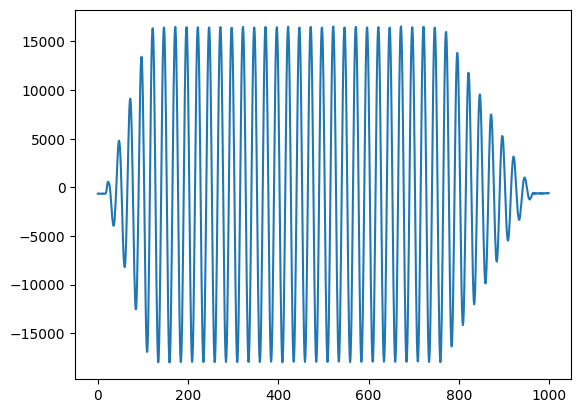

Device: rp_0@192.168.1.143
Frame: rf up and down
Acquisition: acq_ch_2 (t=1, dec=1, samples=1000)


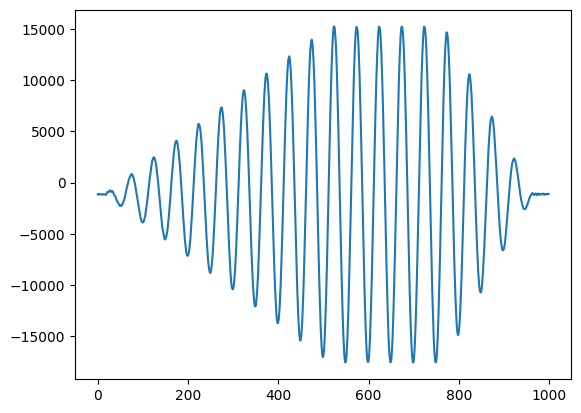

In [64]:
scope_dict = seq.get_scope()

for device_id in scope_dict.keys():
    for frame_label in scope_dict[device_id].keys():
        for scope_label in scope_dict[device_id][frame_label].keys():
            for acq_label in scope_dict[device_id][frame_label][scope_label].keys():
                t = scope_dict[device_id][frame_label][scope_label][acq_label]["t"]
                dec = scope_dict[device_id][frame_label][scope_label][acq_label]["dec"]
                samples = scope_dict[device_id][frame_label][scope_label][acq_label]["samples"]
                data = scope_dict[device_id][frame_label][scope_label][acq_label]["data"]
                print(f"Device: {device_id}")
                print(f"Frame: {frame_label}")
                print(f"Acquisition: {acq_label} (t={t}, dec={dec}, samples={samples})")
                plt.figure()
                plt.plot(data)
                plt.show()
    